### 0. 开始

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import os
import utils_z
import cityjson_parser as cjpar
import time

In [4]:
conn = utils_z.get_conn("Test20260413", "postgres", "we6666", "localhost", "5432")

### 1. 处理 CityGML 数据并导入数据库

#### 1.1 测试：使用 citygml-tools 将1个 lod1 CityGML 转换为 CityJSON

In [4]:
citygml_tools_path = r"E:\0_mylib\citygml-tools-2.4.1\citygml-tools.bat"

utils_z.run_cmd(f'"{citygml_tools_path}" --version')

citygml-tools version 2.4.1
(C) 2018-2026 Claus Nagel <claus.nagel@gmail.com>




CompletedProcess(args='"E:\\0_mylib\\citygml-tools-2.4.1\\citygml-tools.bat" --version', returncode=0, stdout='citygml-tools version 2.4.1\n(C) 2018-2026 Claus Nagel <claus.nagel@gmail.com>\n\n', stderr='')

In [ ]:
test_xml_path = "E:\\2_data\\building_3d_opensource\\hamburg\\LoD2-DE_HH_2025-03-14\\LoD2_32_557_5932_1_HH.xml"

utils_z.run_cmd(f'"{citygml_tools_path}" to-cityjson {test_xml_path}')

[10:27:39 INFO] Starting citygml-tools.
[10:27:39 INFO] Executing 'to-cityjson' command.
[10:27:40 INFO] [1|1] Processing file E:\2_data\building_3d_opensource\hamburg\LoD2-DE_HH_2025-03-14\LoD2_32_557_5932_1_HH.xml.
[10:27:40 INFO] Writing output to file E:\2_data\building_3d_opensource\hamburg\LoD2-DE_HH_2025-03-14\LoD2_32_557_5932_1_HH.json.
[10:27:41 INFO] Total execution time: 01 s.
[10:27:41 INFO] citygml-tools successfully completed.



CompletedProcess(args='"E:\\0_mylib\\citygml-tools-2.4.1\\citygml-tools.bat" to-cityjson E:\\2_data\\building_3d_opensource\\hamburg\\LoD2-DE_HH_2025-03-14\\LoD2_32_557_5932_1_HH.xml', returncode=0, stdout="[10:27:39 INFO] Starting citygml-tools.\n[10:27:39 INFO] Executing 'to-cityjson' command.\n[10:27:40 INFO] [1|1] Processing file E:\\2_data\\building_3d_opensource\\hamburg\\LoD2-DE_HH_2025-03-14\\LoD2_32_557_5932_1_HH.xml.\n[10:27:40 INFO] Writing output to file E:\\2_data\\building_3d_opensource\\hamburg\\LoD2-DE_HH_2025-03-14\\LoD2_32_557_5932_1_HH.json.\n[10:27:41 INFO] Total execution time: 01 s.\n[10:27:41 INFO] citygml-tools successfully completed.\n", stderr='')

#### 1.2 测试：解析并检查一个 CityJSON 数据

In [10]:
import json

test_json_path = test_xml_path.replace('.xml', '.json')
with open(test_json_path, "r", encoding="utf-8") as f:
    data = json.load(f)

# 查看顶层结构
print(data.keys())

# 查看第一栋建筑的属性
first_building_id = list(data["CityObjects"].keys())[0]
first_building = data["CityObjects"][first_building_id]
print(f"\n建筑ID：{first_building_id}")
print(f"类型：{first_building['type']}")
print(f"属性：{json.dumps(first_building.get('attributes', {}), indent=2, ensure_ascii=False)}")
print(f"几何类型：{[g['type'] for g in first_building.get('geometry', [])]}")

dict_keys(['type', 'version', 'CityObjects', 'transform', 'vertices', 'metadata'])

建筑ID：DEHHALKAJ0000nVM
类型：Building
属性：{
  "creationDate": "2023-02-23T00:00:00+08:00",
  "DatenquelleLage": "1000",
  "DatenquelleBodenhoehe": "1100",
  "Gemeindeschluessel": "02100141",
  "DatenquelleDachhoehe": "1000",
  "DatenquelleGeschossanzahl": "1000",
  "Geometrietyp2DReferenz": "3000",
  "Grundrissaktualitaet": "2025-01-27",
  "measuredHeight": 2.297,
  "function": "31001_2460",
  "roofType": "1000",
  "storeysAboveGround": 1
}
几何类型：['Solid']


In [11]:
first_geom = first_building["geometry"][0]
print(f"几何类型：{first_geom['type']}")
print(f"lod：{first_geom.get('lod')}")

# 看看boundaries结构
boundaries = first_geom["boundaries"]
print(f"faces数量：{len(boundaries[0])}")
print(f"第一个face：{boundaries[0][0]}")

# 看看transform
print(f"\ntransform：{json.dumps(data['transform'], indent=2)}")
print(f"vertices总数：{len(data['vertices'])}")
print(f"前3个顶点：{data['vertices'][:3]}")

几何类型：Solid
lod：2
faces数量：6
第一个face：[[0, 1, 2, 3]]

transform：{
  "scale": [
    0.001,
    0.001,
    0.001
  ],
  "translate": [
    556975.486,
    5931992.369,
    1.289
  ]
}
vertices总数：7113
前3个顶点：[[649337, 96570, 6982], [649355, 101950, 6982], [640848, 101981, 6982]]


In [9]:
buildings = cjpar.parse_cityjson_lod1(test_json_path)

print(f"解析出建筑数：{len(buildings)}")
b = buildings[0]
print(f"ID：{b['building_id']}")
print(f"高度：{b['height']}")
print(f"楼层：{b['floor_count']}")
print(f"功能：{b['function']}")
print(f"2D footprint：{b['geom_2d']}")

解析出建筑数：1110
ID：DEHHALKA10005SAX
高度：6.88
楼层：2
功能：31001_1010
2D footprint：POLYGON ((549374.76 5936958.141, 549386.416 5936958.461, 549386.675 5936949.114, 549377.3200000001 5936948.865999999, 549375.024 5936948.796, 549374.888 5936953.3889999995, 549374.76 5936958.141))


#### 1.3 批量转换，创建建筑lod1数据库表并导入数据

In [ ]:
# xml批量转换为json
batch_json_output_dir = "E:\\2_data\\building_3d_opensource\\hamburg\\lod1_json"
batch_xml_input_dir = "E:\\2_data\\building_3d_opensource\\hamburg\\LoD1-DE_HH_2023-04-01"

xml_files = [f for f in os.listdir(batch_xml_input_dir) if f.endswith(".xml")]
print(f"共{len(xml_files)}个文件待转换")

errors = []
for i, filename in enumerate(xml_files):
    input_path = os.path.join(batch_xml_input_dir, filename)
    cmd = f'"{citygml_tools_path}" to-cityjson --output="{batch_json_output_dir}" "{input_path}"'
    try:
        utils_z.run_cmd(cmd)
        if (i + 1) % 50 == 0:
            print(f"进度：{i + 1}/{len(xml_files)}")
    except Exception as e:
        errors.append((filename, str(e)))
        print(f"错误：{filename} -> {e}")

print(f"转换完成，失败{len(errors)}个")

In [3]:
# 创建LOD1建筑表
utils_z.run_sql("""
                CREATE TABLE IF NOT EXISTS hamburg_buildings_lod1
                (
                    building_id
                    VARCHAR
                    PRIMARY
                    KEY,
                    geom_2d
                    GEOMETRY
                (
                    Polygon,
                    25832
                ),
                    height FLOAT,
                    floor_count INTEGER,
                    function VARCHAR,
                    roof_type VARCHAR,
                    year_built INTEGER,
                    geom_3d GEOMETRY
                (
                    PolyhedralSurfaceZ,
                    25832
                )
                    );
                """, conn=conn)

utils_z.run_sql("CREATE INDEX IF NOT EXISTS buildings_lod1_geom_idx ON hamburg_buildings_lod1 USING GIST (geom_2d);",
                conn=conn)
print("LOD1建筑表创建完成")

LOD1建筑表创建完成


In [16]:
json_files = [f for f in os.listdir(batch_json_output_dir) if f.endswith(".json")]
print(f"共{len(json_files)}个文件待处理")

total = 0
errors = []

for i, filename in enumerate(json_files):
    filepath = os.path.join(batch_json_output_dir, filename)
    try:
        buildings = cjpar.parse_cityjson_lod1(filepath)
        print(f"\rProcessing {filename}: {len(buildings)} buildings", end='', flush=True)
        count = cjpar.insert_buildings_lod1(buildings, conn, lod1_table="hamburg_buildings_lod1")
        total += count
        if (i + 1) % 50 == 0:
            print()
            print(f"进度：{i + 1}/{len(json_files)}，已入库建筑：{total}")
    except Exception as e:
        errors.append((filename, str(e)))
        print(f"错误：{filename} -> {e}")

print()  # To move to the next line after the loop
print(f"\n完成！共入库建筑：{total}")
print(f"失败文件数：{len(errors)}")

共784个文件待处理
Processing LoD1_32_554_5924_1_HH.json: 916 buildingss进度：50/784，已入库建筑：15328
Processing LoD1_32_557_5926_1_HH.json: 1033 buildings进度：100/784，已入库建筑：38867
Processing LoD1_32_559_5938_1_HH.json: 539 buildingss进度：150/784，已入库建筑：68189
Processing LoD1_32_561_5937_1_HH.json: 779 buildingss进度：200/784，已入库建筑：88981
Processing LoD1_32_563_5933_1_HH.json: 629 buildingss进度：250/784，已入库建筑：116545
Processing LoD1_32_565_5930_1_HH.json: 475 buildingss进度：300/784，已入库建筑：153498
Processing LoD1_32_567_5921_1_HH.json: 268 buildingss进度：350/784，已入库建筑：179724
Processing LoD1_32_568_5944_1_HH.json: 914 buildingss进度：400/784，已入库建筑：207030
Processing LoD1_32_570_5941_1_HH.json: 551 buildingss进度：450/784，已入库建筑：227768
Processing LoD1_32_572_5930_1_HH.json: 305 buildingss进度：500/784，已入库建筑：254366
Processing LoD1_32_573_5947_1_HH.json: 523 buildingss进度：550/784，已入库建筑：291165
Processing LoD1_32_575_5930_1_HH.json: 1 buildingssss进度：600/784，已入库建筑：314181
Processing LoD1_32_576_5945_1_HH.json: 632 buildingss进度：650/784，已入库建筑：

#### 1.4 （Deprecated）更新block表

In [18]:
result = utils_z.run_sql("""
                         SELECT constraint_name
                         FROM information_schema.table_constraints
                         WHERE table_name = 'hamburg_blocks'
                           AND constraint_type = 'PRIMARY KEY';
                         """, conn=conn, fetch=True)

print(result)

[('blocks_pkey',)]


In [19]:
# 1. 添加新字段
utils_z.run_sql("""
                ALTER TABLE hamburg_blocks
                    ADD COLUMN IF NOT EXISTS city VARCHAR,
                    ADD COLUMN IF NOT EXISTS country VARCHAR,
                    ADD COLUMN IF NOT EXISTS area_m2 FLOAT;
                """, conn=conn)

# 2. 填入城市、国家、面积
utils_z.run_sql("""
                UPDATE hamburg_blocks
                SET city    = 'Hamburg',
                    country = 'Germany',
                    area_m2 = ST_Area(geom);
                """, conn=conn)

# 3. 删除主键约束
utils_z.run_sql("""
                ALTER TABLE hamburg_blocks
                DROP
                CONSTRAINT blocks_pkey;
                """, conn=conn)

# 4. 把block_id从INTEGER改为VARCHAR，同时替换为新格式
utils_z.run_sql("""
                ALTER TABLE hamburg_blocks
                ALTER
                COLUMN block_id TYPE VARCHAR
    USING 'DE_HH_' || LPAD(block_id::TEXT, 6, '0');
                """, conn=conn)

# 5. 重新设置主键
utils_z.run_sql("""
                ALTER TABLE hamburg_blocks
                    ADD PRIMARY KEY (block_id);
                """, conn=conn)

print("改造完成")

# 验证
result = utils_z.run_sql("""
                         SELECT block_id, city, country, area_m2
                         FROM hamburg_blocks LIMIT 5;
                         """, conn=conn, fetch=True)

for row in result:
    print(row)

改造完成
('DE_HH_000003', 'Hamburg', 'Germany', 146583.28380672264)
('DE_HH_000004', 'Hamburg', 'Germany', 68077.03149206015)
('DE_HH_000006', 'Hamburg', 'Germany', 42258.92792725274)
('DE_HH_000007', 'Hamburg', 'Germany', 64097.37637555693)
('DE_HH_000155', 'Hamburg', 'Germany', 18986.38463513086)


#### 1.5 街区与建筑空间叠合，记录建筑所属的街区

In [20]:
# 添加block_id字段
utils_z.run_sql("""
                ALTER TABLE hamburg_buildings_lod1
                    ADD COLUMN IF NOT EXISTS block_id VARCHAR;
                """, conn=conn)

# 建立空间索引
utils_z.run_sql("""
                CREATE INDEX IF NOT EXISTS buildings_lod1_geom_idx
                    ON hamburg_buildings_lod1 USING GIST (geom_2d);
                """, conn=conn)

print("字段和索引准备完成，开始空间叠合...")

字段和索引准备完成，开始空间叠合...


In [22]:
# 用重心落点规则批量判定
start_time = time.time()

utils_z.run_sql("""
                UPDATE hamburg_buildings_lod1 b
                SET block_id = (SELECT bl.block_id
                                FROM hamburg_blocks bl
                                WHERE ST_Within(ST_Centroid(b.geom_2d), bl.geom)
                    LIMIT 1
                    );
                """, conn=conn)

end_time = time.time()
elapsed_time = end_time - start_time
print(f"空间叠合完成，耗时：{elapsed_time:.2f}秒")


空间叠合完成，耗时：23.50秒


In [23]:
# 检查数据结果
result = utils_z.run_sql("""
                         SELECT COUNT(*)        AS total,
                                COUNT(block_id) AS matched,
                                COUNT(*)           FILTER (WHERE block_id IS NULL) AS unmatched
                         FROM hamburg_buildings_lod1;
                         """, conn=conn, fetch=True)

print(f"总建筑数：{result[0][0]}")
print(f"成功匹配block：{result[0][1]}")
print(f"未匹配block：{result[0][2]}")

总建筑数：384629
成功匹配block：354272
未匹配block：30357


#### 1.6 绘制检查

In [3]:
import geopandas as gpd
from shapely.geometry import Polygon, MultiPolygon
import py5

In [6]:
# 随机选取100个有建筑的block
sql_blocks = """
             SELECT block_id, geom
             FROM hamburg_blocks
             WHERE block_id IN (SELECT DISTINCT block_id
                                FROM hamburg_buildings_lod1
                                WHERE block_id IS NOT NULL)
             ORDER BY RANDOM() LIMIT 50; \
             """
gdf_blocks = gpd.read_postgis(sql_blocks, conn, geom_col="geom", crs="EPSG:25832")
blocks = list(gdf_blocks.itertuples(index=False, name='Block'))
print(f"随机选取了 {len(blocks)} 个block")

# 预加载所有建筑数据
buildings_data = {}
for block in blocks:
    block_id = block.block_id
    sql_buildings = f"""
        SELECT building_id, geom_2d
        FROM hamburg_buildings_lod1
        WHERE block_id = '{block_id}';
    """
    gdf_buildings = gpd.read_postgis(sql_buildings, conn, geom_col="geom_2d", crs="EPSG:25832")
    buildings_data[block_id] = list(gdf_buildings.geometry)

# 全局变量
current_index = 0


def all_polygons(g):
    if isinstance(g, Polygon):
        return [g]
    elif isinstance(g, MultiPolygon):
        return list(g.geoms)
    return []


def draw_polygon(poly, is_building=False):
    """绘制单个polygon，根据是否是建筑设置不同颜色"""
    coords = list(poly.exterior.coords)
    if is_building:
        py5.fill(180, 100, 100)  # 建筑：红棕色
        py5.stroke(120, 60, 60)
    else:
        py5.fill(220, 220, 210)  # block：浅灰色
        py5.stroke(80, 80, 80)

    py5.begin_shape()
    for x, y in coords:
        py5.vertex(x, y)
    py5.end_shape(py5.CLOSE)


def draw_current_block():
    global current_index
    if current_index < 0 or current_index >= len(blocks):
        return

    block = blocks[current_index]
    block_id = block.block_id
    block_geom = block.geom

    buildings_geoms = buildings_data[block_id]

    py5.background(240)

    W, H = py5.width, py5.height
    minx, miny, maxx, maxy = block_geom.bounds
    cw = maxx - minx
    ch = maxy - miny
    margin = 0.15
    scale = min((W * (1 - margin)) / cw, (H * (1 - margin)) / ch)
    cx = (minx + maxx) / 2
    cy = (miny + maxy) / 2

    py5.push_matrix()
    py5.translate(W / 2, H / 2)
    py5.scale(scale, -scale)
    py5.translate(-cx, -cy)

    # 先画block轮廓
    py5.stroke_weight(1 / scale)
    for p in all_polygons(block_geom):
        draw_polygon(p, is_building=False)

    # 再画建筑footprint
    py5.stroke_weight(0.5 / scale)
    for geom in buildings_geoms:
        for p in all_polygons(geom):
            draw_polygon(p, is_building=True)

    py5.pop_matrix()

    # 显示当前block信息
    py5.fill(0)
    py5.text_size(16)
    py5.text(f"Block: {block_id} ({current_index + 1}/{len(blocks)})", 10, 20)


def setup():
    py5.size(900, 900)
    draw_current_block()


def draw():
    pass  # 静态绘制


def key_pressed():
    global current_index
    if py5.key == '1':
        current_index = max(0, current_index - 1)
        draw_current_block()
    elif py5.key == '2':
        current_index = min(len(blocks) - 1, current_index + 1)
        draw_current_block()


py5.run_sketch()


随机选取了 50 个block


### 2 处理lod2的CityGML数据

#### 2.0 所有与城市名相关的变量

In [6]:
block_table_name = "hamburg" + "_blocks"
lod1_table_name = "hamburg" + "_buildings_lod1"
lod2_table_name = "hamburg" + "_buildings_lod2"
lod2_surface_table_name  = "hamburg" + "_building_surfaces_lod2"
city_prefix  = "DE_HH"
target_srid  = 25832
source_srid  = 31256

#### 2.1 测试：任选一个lod2的xml并转换为json，然后解析数据做检查

In [3]:
citygml_tools_path = r"E:\0_mylib\citygml-tools-2.4.1\citygml-tools.bat"

utils_z.run_cmd(f'"{citygml_tools_path}" --version')

citygml-tools version 2.4.1
(C) 2018-2026 Claus Nagel <claus.nagel@gmail.com>




CompletedProcess(args='"E:\\0_mylib\\citygml-tools-2.4.1\\citygml-tools.bat" --version', returncode=0, stdout='citygml-tools version 2.4.1\n(C) 2018-2026 Claus Nagel <claus.nagel@gmail.com>\n\n', stderr='')

In [6]:
test_xml_path = "E:\\2_data\\building_3d_opensource\\vienna\\gml\\079086.gml"

utils_z.run_cmd(f'"{citygml_tools_path}" to-cityjson {test_xml_path}')

[11:10:06 INFO] Starting citygml-tools.
[11:10:06 INFO] Executing 'to-cityjson' command.
[11:10:06 INFO] [1|1] Processing file E:\2_data\building_3d_opensource\vienna\gml\079086.gml.
[11:10:07 WARN] The input file uses unsupported non-CityGML namespaces: http://www.citygml.org/citygml/profiles/base/1.0, http://www.w3.org/2001/SMIL20/Language, http://www.w3.org/2001/SMIL20/, http://www.ascc.net/xml/schematron.
[11:10:07 INFO] Non-CityGML content is skipped unless a matching ADE extension has been loaded.
[11:10:07 INFO] Writing output to file E:\2_data\building_3d_opensource\vienna\gml\079086.json.
[11:10:07 INFO] Total execution time: 01 s.
[11:10:07 INFO] citygml-tools finished with 1 warning(s).



CompletedProcess(args='"E:\\0_mylib\\citygml-tools-2.4.1\\citygml-tools.bat" to-cityjson E:\\2_data\\building_3d_opensource\\vienna\\gml\\079086.gml', returncode=0, stdout="[11:10:06 INFO] Starting citygml-tools.\n[11:10:06 INFO] Executing 'to-cityjson' command.\n[11:10:06 INFO] [1|1] Processing file E:\\2_data\\building_3d_opensource\\vienna\\gml\\079086.gml.\n[11:10:07 WARN] The input file uses unsupported non-CityGML namespaces: http://www.citygml.org/citygml/profiles/base/1.0, http://www.w3.org/2001/SMIL20/Language, http://www.w3.org/2001/SMIL20/, http://www.ascc.net/xml/schematron.\n[11:10:07 INFO] Non-CityGML content is skipped unless a matching ADE extension has been loaded.\n[11:10:07 INFO] Writing output to file E:\\2_data\\building_3d_opensource\\vienna\\gml\\079086.json.\n[11:10:07 INFO] Total execution time: 01 s.\n[11:10:07 INFO] citygml-tools finished with 1 warning(s).\n", stderr='')

In [7]:
import json

# test_json_path = test_xml_path.replace('.xml', '.json')
test_json_path = test_xml_path.replace('.gml', '.json')
with open(test_json_path, "r", encoding="utf-8") as f:
    data = json.load(f)

# 查看顶层结构
print(data.keys())

# 查看第一栋建筑的属性
first_building_id = list(data["CityObjects"].keys())[0]
first_building = data["CityObjects"][first_building_id]
print(f"\n建筑ID：{first_building_id}")
print(f"类型：{first_building['type']}")
print(f"属性：{json.dumps(first_building.get('attributes', {}), indent=2, ensure_ascii=False)}")
print(f"几何类型：{[g['type'] for g in first_building.get('geometry', [])]}")

dict_keys(['type', 'version', 'CityObjects', 'transform', 'vertices', 'metadata'])

建筑ID：UUID_LOD2_043487-19998f4b-698f-4cee-a08c_1
类型：BuildingPart
属性：{
  "creationDate": "2016-09-29T00:00:00+08:00",
  "Blattnummer": "079086",
  "HoeheDach": "135",
  "HoeheGrund": "132",
  "NiedrigsteTraufeDesGebaeudes": "135",
  "measuredHeight": 3.86,
  "roofType": "FLACHDACH"
}
几何类型：['Solid']


In [8]:
# 查看LOD2的几何边界详细结构
first_geom = first_building["geometry"][0]
boundaries = first_geom["boundaries"]
semantics = first_geom.get("semantics", {})

print(f"semantics keys: {semantics.keys()}")
print(f"surfaces: {json.dumps(semantics.get('surfaces', []), indent=2)}")
print(f"values: {semantics.get('values', [])}")

semantics keys: dict_keys(['surfaces', 'values'])
surfaces: [
  {
    "type": "WallSurface",
    "id": "UUID_LOD2_043487-19998f4b-698f-4cee-a08c_7f1bbb9a-a16b-41c3-9f79-5ac38ebf17a6_2",
    "Flaeche": "13.17",
    "FlaechenUUID": "7f1bbb9a-a16b-41c3-9f79-5ac38ebf17a6"
  },
  {
    "type": "WallSurface",
    "id": "UUID_LOD2_043487-19998f4b-698f-4cee-a08c_73cd59b0-7f5c-4c6a-83e2-df85b778b6df_2",
    "Flaeche": "17.8",
    "FlaechenUUID": "73cd59b0-7f5c-4c6a-83e2-df85b778b6df"
  },
  {
    "type": "WallSurface",
    "id": "UUID_LOD2_043487-19998f4b-698f-4cee-a08c_c3828d70-f61f-498c-aa26-0acda0090e4d_2",
    "Flaeche": "3.91",
    "FlaechenUUID": "c3828d70-f61f-498c-aa26-0acda0090e4d"
  },
  {
    "type": "WallSurface",
    "id": "UUID_LOD2_043487-19998f4b-698f-4cee-a08c_df8e1237-0148-47ca-b8f6-774b3c48f5ba_2",
    "Flaeche": "20.13",
    "FlaechenUUID": "df8e1237-0148-47ca-b8f6-774b3c48f5ba"
  },
  {
    "type": "WallSurface",
    "id": "UUID_LOD2_043487-19998f4b-698f-4cee-a08c_a9e24421-

In [9]:
with open(test_json_path, "r", encoding="utf-8") as f:
    data = json.load(f)

first_id = list(data["CityObjects"].keys())[0]
first_obj = data["CityObjects"][first_id]
geom_entry = next((g for g in first_obj.get("geometry", []) if str(g.get("lod")) == "2"), None)

semantics = geom_entry.get("semantics", {})
print(f"surfaces: {json.dumps(semantics.get('surfaces', []), indent=2)}")
print(f"values原始结构: {semantics.get('values')}")
print(f"values类型: {type(semantics.get('values'))}")
print(f"values长度: {len(semantics.get('values', []))}")

surfaces: [
  {
    "type": "WallSurface",
    "id": "UUID_LOD2_043487-19998f4b-698f-4cee-a08c_7f1bbb9a-a16b-41c3-9f79-5ac38ebf17a6_2",
    "Flaeche": "13.17",
    "FlaechenUUID": "7f1bbb9a-a16b-41c3-9f79-5ac38ebf17a6"
  },
  {
    "type": "WallSurface",
    "id": "UUID_LOD2_043487-19998f4b-698f-4cee-a08c_73cd59b0-7f5c-4c6a-83e2-df85b778b6df_2",
    "Flaeche": "17.8",
    "FlaechenUUID": "73cd59b0-7f5c-4c6a-83e2-df85b778b6df"
  },
  {
    "type": "WallSurface",
    "id": "UUID_LOD2_043487-19998f4b-698f-4cee-a08c_c3828d70-f61f-498c-aa26-0acda0090e4d_2",
    "Flaeche": "3.91",
    "FlaechenUUID": "c3828d70-f61f-498c-aa26-0acda0090e4d"
  },
  {
    "type": "WallSurface",
    "id": "UUID_LOD2_043487-19998f4b-698f-4cee-a08c_df8e1237-0148-47ca-b8f6-774b3c48f5ba_2",
    "Flaeche": "20.13",
    "FlaechenUUID": "df8e1237-0148-47ca-b8f6-774b3c48f5ba"
  },
  {
    "type": "WallSurface",
    "id": "UUID_LOD2_043487-19998f4b-698f-4cee-a08c_a9e24421-5343-4fdf-9f6d-2e5f26225233_2",
    "Flaeche": "9.

In [10]:
test_buildings = cjpar.parse_cityjson_lod2(test_json_path)
print(f"解析出建筑数：{len(test_buildings)}")
b = test_buildings[0]
print(f"ID：{b['building_id']}")
print(f"高度：{b['height']}")
print(f"2D footprint：{b['geom_2d']}")
print(f"RoofSurface数量：{len(b['surfaces']['RoofSurface'])}")
print(f"WallSurface数量：{len(b['surfaces']['WallSurface'])}")
print(f"GroundSurface数量：{len(b['surfaces']['GroundSurface'])}")

解析出建筑数：71
ID：UUID_LOD2_043487-afff66a4-f580-423c-aad7
高度：3.0
2D footprint：POLYGON ((-10095.57 343412.25999999995, -10097.81 343410.62, -10100 343413.00999999995, -10102.519999999999 343415.75999999995, -10100.01 343417.49, -10095.57 343412.25999999995))
RoofSurface数量：1
WallSurface数量：5
GroundSurface数量：1


#### 2.2 创建LOD2建筑表并批量转换、导入数据

In [8]:
# 先批量转换XML到CityJSON
lod2_xml_dir = r"E:\2_data\building_3d_opensource\vienna\gml"
lod2_json_dir = r"E:\2_data\building_3d_opensource\vienna\lod2_json"
os.makedirs(lod2_json_dir, exist_ok=True)

In [ ]:
# xml_files = [f for f in os.listdir(lod2_xml_dir) if f.endswith(".xml")]
xml_files = [f for f in os.listdir(lod2_xml_dir) if f.endswith(".gml")]
print(f"共{len(xml_files)}个文件待转换")

errors = [] 
for i, filename in enumerate(xml_files):
    input_path = os.path.join(lod2_xml_dir, filename)
    cmd = f'"{citygml_tools_path}" to-cityjson --output="{lod2_json_dir}" "{input_path}"'
    try:
        utils_z.run_cmd(cmd, False)
        if (i + 1) % 50 == 0:
            print(f"转换进度：{i + 1}/{len(xml_files)}")
    except Exception as e:
        errors.append((filename, str(e)))
        print(f"转换错误：{filename} -> {e}")

print(f"转换完成，失败{len(errors)}个")

共1459个文件待转换
转换进度：50/1459
转换进度：100/1459
转换进度：150/1459
转换进度：200/1459
转换进度：250/1459
转换进度：300/1459
转换进度：350/1459
转换进度：400/1459
转换进度：450/1459
转换进度：500/1459
转换进度：550/1459
转换进度：600/1459
转换进度：650/1459
转换进度：700/1459
转换进度：750/1459
转换进度：800/1459
转换进度：850/1459
转换进度：900/1459
转换进度：950/1459
转换进度：1000/1459
转换进度：1050/1459
转换进度：1100/1459
转换进度：1150/1459
转换进度：1200/1459
转换进度：1250/1459
转换进度：1300/1459
转换进度：1350/1459
转换进度：1400/1459
转换进度：1450/1459
转换完成，失败0个


In [5]:
# 建表前先创建序列
utils_z.run_sql(f"""
    CREATE SEQUENCE IF NOT EXISTS {lod2_table_name}_seq;
""", conn=conn)

utils_z.run_sql(f"""
    CREATE SEQUENCE IF NOT EXISTS {lod2_surface_table_name}_seq;
""", conn=conn)

# LOD2建筑主表
utils_z.run_sql(f"""
    CREATE TABLE IF NOT EXISTS {lod2_table_name} (
        building_id     VARCHAR PRIMARY KEY 
                        DEFAULT '{city_prefix}_B_' || LPAD(NEXTVAL('{lod2_table_name}_seq')::TEXT, 7, '0'),
        block_id        VARCHAR,
        citygml_id      VARCHAR,
        geom_2d         GEOMETRY(Polygon, {target_srid}),
        height          FLOAT,
        floor_count     INTEGER,
        function        VARCHAR,
        roof_type       VARCHAR,
        year_built      INTEGER
    );
""", conn=conn)

utils_z.run_sql(f"""
    CREATE INDEX IF NOT EXISTS {lod2_table_name}_geom_idx
    ON {lod2_table_name} USING GIST (geom_2d);
""", conn=conn)

# LOD2 surface子表
utils_z.run_sql(f"""
    CREATE TABLE IF NOT EXISTS {lod2_surface_table_name} (
        surface_id      VARCHAR PRIMARY KEY
                        DEFAULT '{city_prefix}_S_' || LPAD(NEXTVAL('{lod2_surface_table_name}_seq')::TEXT, 8, '0'),
        citygml_id      VARCHAR,
        building_id     VARCHAR REFERENCES {lod2_table_name}(building_id),
        surface_type    VARCHAR,
        geom_3d         GEOMETRY(PolygonZ, {target_srid})
    );
""", conn=conn)

utils_z.run_sql(f"""
    CREATE INDEX IF NOT EXISTS {lod2_surface_table_name}_building_idx
    ON {lod2_surface_table_name} (building_id);
""", conn=conn)

print(city_prefix+" LOD2表创建完成")

AT_VI LOD2表创建完成


In [6]:
import traceback

In [9]:
json_files = [f for f in os.listdir(lod2_json_dir) if f.endswith(".json")]
print(f"共{len(json_files)}个文件待入库")

total = 0
errors = []
building_counter = 1
surface_counter = 1

for i, filename in enumerate(json_files):
    filepath = os.path.join(lod2_json_dir, filename)
    try:
        buildings = cjpar.parse_cityjson_lod2(filepath)
        count, building_counter, surface_counter = cjpar.insert_buildings_lod2(
            buildings, conn,
            lod2_table=lod2_table_name,
            surface_table=lod2_surface_table_name,
            city_prefix=city_prefix,
            target_srid=target_srid,
            source_srid=source_srid,
            building_counter=building_counter,
            surface_counter=surface_counter
        )
        total += count
        if (i + 1) % 50 == 0:
            print(f"入库进度：{i+1}/{len(json_files)}，已入库建筑：{total}，已入库表面：{surface_counter-1}")
    except Exception as e:
        errors.append((filename, str(e)))
        print(f"错误：{filename} -> {e}")
        traceback.print_exc()

print(f"\n完成！共入库建筑：{total}，共入库表面：{surface_counter-1}")

print(f"失败文件数：{len(errors)}")

共1459个文件待入库
入库进度：50/1459，已入库建筑：3302，已入库表面：40287
入库进度：100/1459，已入库建筑：11951，已入库表面：136760
入库进度：150/1459，已入库建筑：28359，已入库表面：339781
入库进度：200/1459，已入库建筑：49013，已入库表面：594921
入库进度：250/1459，已入库建筑：72525，已入库表面：899620
入库进度：300/1459，已入库建筑：92136，已入库表面：1132108
入库进度：350/1459，已入库建筑：114224，已入库表面：1435909
入库进度：400/1459，已入库建筑：137265，已入库表面：1738993
入库进度：450/1459，已入库建筑：166458，已入库表面：2171938
入库进度：500/1459，已入库建筑：187852，已入库表面：2517195
入库进度：550/1459，已入库建筑：213876，已入库表面：2966296
入库进度：600/1459，已入库建筑：233531，已入库表面：3299241
入库进度：650/1459，已入库建筑：256837，已入库表面：3721186
入库进度：700/1459，已入库建筑：274923，已入库表面：4012271
入库进度：750/1459，已入库建筑：292063，已入库表面：4273306
入库进度：800/1459，已入库建筑：312369，已入库表面：4593044
入库进度：850/1459，已入库建筑：326876，已入库表面：4792382
入库进度：900/1459，已入库建筑：340871，已入库表面：4990200
入库进度：950/1459，已入库建筑：355195，已入库表面：5194238
入库进度：1000/1459，已入库建筑：369691，已入库表面：5384086
入库进度：1050/1459，已入库建筑：386146，已入库表面：5580325
入库进度：1100/1459，已入库建筑：399689，已入库表面：5747693
入库进度：1150/1459，已入库建筑：416031，已入库表面：5944881
入库进度：1200/1459，已入库建筑：430867，已入库表面：6142058
入库进度：1250/145

In [58]:
with open("E:\\2_data\\building_3d_opensource\\vienna\\lod2_json\\097094.json") as f:
    data = json.load(f)

# 找到有问题的对象，看它的geometry结构
for obj_id, obj in data["CityObjects"].items():
    if obj["type"] in ("Building", "BuildingPart"):
        geom_entry = next((g for g in obj.get("geometry", []) if str(g.get("lod")) == "2"), None)
        if geom_entry:
            print(obj_id, obj["type"])
            print("boundaries结构:", geom_entry["boundaries"][:2])  # 只看前两个
            print("semantics:", geom_entry.get("semantics", {}))
            print("---")

UUID_LOD2_061041-067e9a6b-7b6c-4a6a-8161 Building
boundaries结构: [[[[0, 1, 2, 3]], [[4, 5, 1, 0]], [[6, 3, 2, 7]], [[8, 5, 4, 9]], [[10, 9, 4, 0, 3, 6]], [[1, 5, 8, 11, 7, 2]], [[9, 10, 6, 7, 11, 8]]]]
semantics: {'surfaces': [{'type': 'RoofSurface', 'id': 'UUID_LOD2_061041-067e9a6b-7b6c-4a6a-8161_db68487b-ad39-4378-8f4e-10672df0e547_2', 'Dachneigung': '70.62', 'Dachorientierung': '335.72', 'Flaeche': '18.57', 'FlaechenUUID': 'db68487b-ad39-4378-8f4e-10672df0e547'}, {'type': 'RoofSurface', 'id': 'UUID_LOD2_061041-067e9a6b-7b6c-4a6a-8161_e3f29d3b-52b0-4a91-ad2e-547f9bc575cd_2', 'Dachneigung': '70.62', 'Dachorientierung': '155.72', 'Flaeche': '18.57', 'FlaechenUUID': 'e3f29d3b-52b0-4a91-ad2e-547f9bc575cd'}, {'type': 'WallSurface', 'id': 'UUID_LOD2_061041-067e9a6b-7b6c-4a6a-8161_6d40d7a7-7f1e-4922-bdf3-9f6aef4909b6_2', 'Flaeche': '18.25', 'FlaechenUUID': '6d40d7a7-7f1e-4922-bdf3-9f6aef4909b6'}, {'type': 'WallSurface', 'id': 'UUID_LOD2_061041-067e9a6b-7b6c-4a6a-8161_b017008e-1ce6-4109-9fb4-

#### 2.3 更新block_id字段并空间叠合

In [11]:
# 建立空间索引
utils_z.run_sql(f"""
    CREATE INDEX IF NOT EXISTS buildings_lod2_geom_idx
    ON {lod2_table_name} USING GIST (geom_2d);
""", conn=conn)

print("开始空间叠合...")

开始空间叠合...


In [12]:
utils_z.run_sql(f"""
    UPDATE {lod2_table_name} b
    SET block_id = (
        SELECT bl.block_id
        FROM {block_table_name} bl
        WHERE ST_Within(ST_Centroid(b.geom_2d), bl.geom)
        LIMIT 1
    );
""", conn=conn)
print("空间叠合完成")

空间叠合完成


In [16]:
# 检查匹配情况
result = utils_z.run_sql(f"""
    SELECT
        COUNT(*) AS total,
        COUNT(block_id) AS matched,
        COUNT(*) FILTER (WHERE block_id IS NULL) AS unmatched
    FROM {lod2_table_name};
""", conn=conn, fetch=True)

print(f"总建筑数：{result[0][0]}")
print(f"成功匹配block：{result[0][1]}")
print(f"未匹配block：{result[0][2]}")

总建筑数：477126
成功匹配block：454262
未匹配block：22864


In [18]:
# 检查包含LOD1和LOD2建筑的街区数量
sql_counts = f"""
    SELECT 
        (SELECT COUNT(DISTINCT block_id) FROM {lod2_table_name} WHERE block_id IS NOT NULL) as lod1_blocks,
        (SELECT COUNT(DISTINCT block_id) FROM {lod2_table_name} WHERE block_id IS NOT NULL) as lod2_blocks;
"""
counts = utils_z.run_sql(sql_counts, conn=conn, fetch=True)
print(f"包含LOD1建筑的街区数量: {counts[0][0]}")
print(f"包含LOD2建筑的街区数量: {counts[0][1]}")

包含LOD1建筑的街区数量: 5871
包含LOD2建筑的街区数量: 5871


##### debug

In [ ]:
# 1. 检查两张表各自的坐标系
print(utils_z.run_sql(f"SELECT Find_SRID('public', '{lod2_table_name}', 'geom_2d');", conn=conn, fetch=True))
print(utils_z.run_sql(f"SELECT Find_SRID('public', '{block_table_name}', 'geom');", conn=conn, fetch=True))

# 2. 看看两张表的坐标范围是否在同一数量级
print(utils_z.run_sql(f"SELECT ST_Extent(geom_2d) FROM {lod2_table_name};", conn=conn, fetch=True))
print(utils_z.run_sql(f"SELECT ST_Extent(geom) FROM {block_table_name};", conn=conn, fetch=True))

# 3. 随便取一栋建筑的centroid，看它落在哪里
print(utils_z.run_sql(f"SELECT ST_AsText(ST_Centroid(geom_2d)) FROM {lod2_table_name} LIMIT 1;", conn=conn, fetch=True))

[(25833,)]
[(0,)]
[('BOX(-10749.27 331389.01,18183.795 353381.93799999997)',)]
[('BOX(589200.6788676552 5330441.177434857,614929.5032929091 5351551.6025656825)',)]
[('POINT(-10212.01 345059.78)',)]


In [ ]:
# 先确认block表建表时的transform目标
# 再用ST_SetSRID强制修正block表的坐标系（如果数据本身是对的只是没登记）
utils_z.run_sql(f"""
    SELECT ST_AsText(geom) FROM {block_table_name} LIMIT 1;
""", conn=conn, fetch=True)


[('POLYGON((589502.8670227258 5342245.796037353,589441.5448576884 5342292.750634647,589406.7026083237 5342314.294902007,589335.6474588497 5342348.668719315,589285.2988223999 5342363.378227262,589251.7038950417 5342371.735374545,589200.6788676552 5342384.600651726,589215.5367276989 5342441.976828558,589222.653586947 5342461.877248411,589250.7802335394 5342501.984416407,589254.2822857167 5342506.986490045,589284.864469873 5342485.096716668,589309.2792616172 5342467.624236941,589489.3078402273 5342338.758993452,589498.2153494882 5342332.539530742,589508.1986397573 5342325.458679183,589518.2171686984 5342318.500689847,589526.9101452322 5342311.755381777,589543.399448982 5342297.18345026,589537.5657849787 5342289.765458014,589502.8670227258 5342245.796037353))',)]

In [ ]:
# 同时看一眼building原始坐标是否合理
utils_z.run_sql(f"""
    SELECT ST_AsText(geom_2d) FROM {lod2_table_name} LIMIT 1;
""", conn=conn, fetch=True)

[('POLYGON((-10215.689999999999 345057.75,-10214.21 345063.36,-10208.33 345061.81,-10209.81 345056.2,-10215.689999999999 345057.75))',)]

In [23]:
with open("E:\\2_data\\building_3d_opensource\\vienna\\lod2_json\\079090.json", "r") as f:
    data = json.load(f)

print("transform:", data["transform"])
print("第一个顶点原始值:", data["vertices"][0])
print("metadata:", data.get("metadata", {}))

transform: {'scale': [0.001, 0.001, 0.001], 'translate': [-10284.81, 344996.82, 129.24]}
第一个顶点原始值: [277792, 442497, 22964]
metadata: {'geographicalExtent': [-10284.81, 344996.82, 129.24, -9996.12, 345465.06, 157.12], 'referenceSystem': 'http://www.opengis.net/def/crs/EPSG/0/31256'}


#### 2.4 绘制检查，轴测三维视角

已选取 30 个block


C:\Users\94017\AppData\Local\Temp\ipykernel_31060\603081477.py:156: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  pl.show()


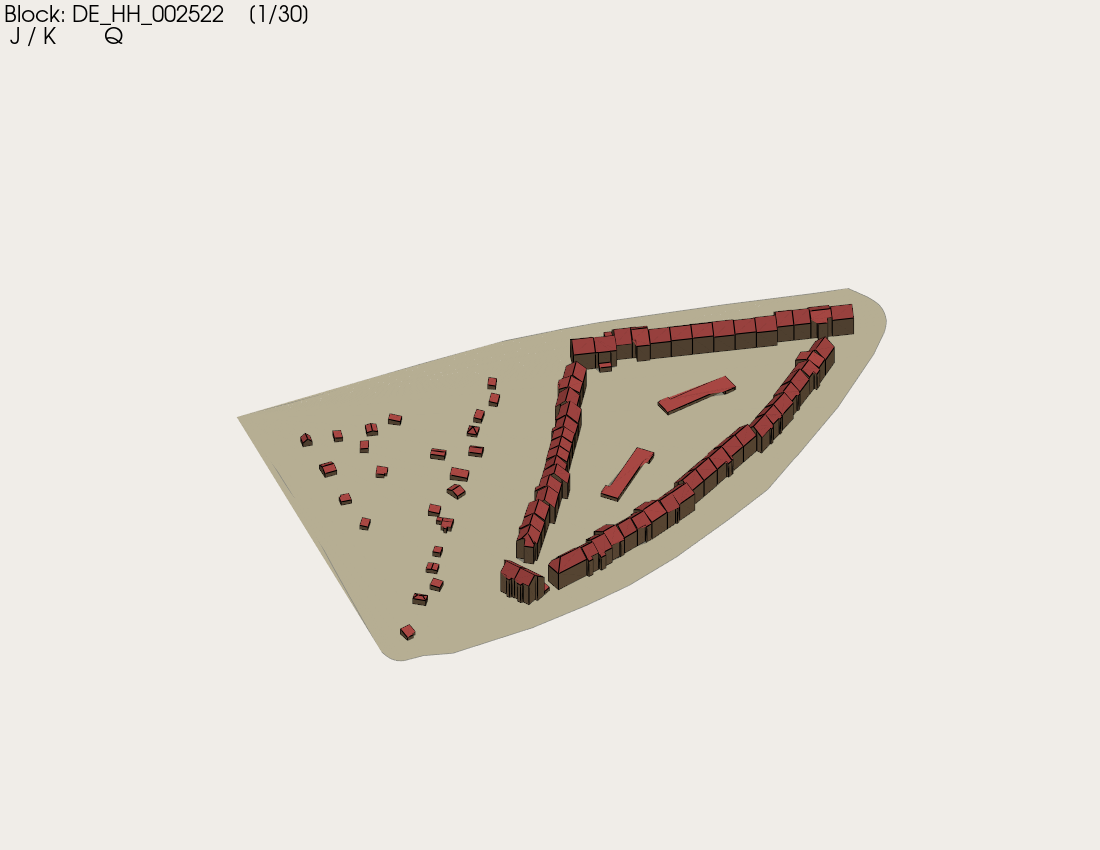

In [7]:
import pyvista as pv
import numpy as np
from shapely.wkt import loads as wkt_loads

# ── 1. 从数据库随机取30个有LOD2建筑的block ──────────────────────────────────
sql_blocks = f"""
    SELECT bl.block_id, ST_AsText(bl.geom) AS geom_wkt
    FROM {block_table_name} bl
    WHERE EXISTS (
        SELECT 1 FROM {lod2_table_name} b
        WHERE b.block_id = bl.block_id
    )
    ORDER BY RANDOM()
    LIMIT 30;
"""
rows = utils_z.run_sql(sql_blocks, conn=conn, fetch=True)
block_ids  = [r[0] for r in rows]
block_wkts = [r[1] for r in rows]
print(f"已选取 {len(block_ids)} 个block")


# ── 2. 查询函数 ───────────────────────────────────────────────────────────────
def fetch_surfaces(block_id):
    sql = f"""
        SELECT s.surface_type, ST_AsText(s.geom_3d) AS geom_wkt
        FROM {lod2_surface_table_name} s
        JOIN {lod2_table_name} b ON s.building_id = b.building_id
        WHERE b.block_id = '{block_id}';
    """
    return utils_z.run_sql(sql, conn=conn, fetch=True)


# ── 3. 几何构建工具 ───────────────────────────────────────────────────────────
def polygon_to_pyvista(coords_3d, cx, cy, base_z):
    """把一组3D坐标转换为PyVista的face数组（去掉闭合重复点）"""
    pts = np.array([[c[0]-cx, c[1]-cy, (c[2] if len(c)>2 else base_z)-base_z]
                    for c in coords_3d[:-1]])   # 去掉最后的重复点
    if len(pts) < 3:
        return None, None
    faces = np.array([len(pts)] + list(range(len(pts))))
    return pts, faces


def build_block_scene(idx):
    """构建第idx个block的完整PyVista场景，返回plotter"""
    block_id  = block_ids[idx]
    block_wkt = block_wkts[idx]
    block_geom = wkt_loads(block_wkt)

    surfaces = fetch_surfaces(block_id)

    # 中心点与基准Z
    minx, miny, maxx, maxy = block_geom.bounds
    cx = (minx + maxx) / 2
    cy = (miny + maxy) / 2

    base_z = float('inf')
    for stype, wkt in surfaces:
        try:
            poly = wkt_loads(wkt)
            for c in poly.exterior.coords:
                if len(c) > 2:
                    base_z = min(base_z, c[2])
        except:
            continue
    if base_z == float('inf'):
        base_z = 0.0

    # ── 创建plotter ─────────────────────────────────────────────────────────
    pl = pv.Plotter(window_size=[1100, 850], title=f"Block {block_id}  [{idx+1}/30]")
    pl.set_background("#F0EDE8")

    # ── 绘制block地面轮廓（拉伸一个薄片）──────────────────────────────────
    block_coords = list(block_geom.exterior.coords)
    pts_2d = np.array([[c[0]-cx, c[1]-cy, -0.2] for c in block_coords[:-1]])
    faces_2d = np.array([len(pts_2d)] + list(range(len(pts_2d))))
    if len(pts_2d) >= 3:
        mesh_block = pv.PolyData(pts_2d, faces_2d)
        pl.add_mesh(mesh_block, color="#C8C4B0", show_edges=True,
                    edge_color="#888880", line_width=1.5, label="Block")

    # ── 颜色映射 ────────────────────────────────────────────────────────────
    color_map = {
        "RoofSurface":   "#B85050",
        "WallSurface":   "#D4A878",
        "GroundSurface": "#909088",
    }

    # 按类型批量收集顶点，减少add_mesh调用次数
    type_points = {"RoofSurface": [], "WallSurface": [], "GroundSurface": [], "Other": []}
    type_faces  = {"RoofSurface": [], "WallSurface": [], "GroundSurface": [], "Other": []}
    type_offset = {"RoofSurface": 0,  "WallSurface": 0,  "GroundSurface": 0,  "Other": 0}

    for stype, wkt in surfaces:
        try:
            poly = wkt_loads(wkt)
            coords_3d = list(poly.exterior.coords)
            pts, faces = polygon_to_pyvista(coords_3d, cx, cy, base_z)
            if pts is None:
                continue
            key = stype if stype in type_points else "Other"
            offset = type_offset[key]
            type_points[key].append(pts)
            # faces数组里的顶点索引需要加上已有顶点的偏移量
            faces[1:] += offset
            type_faces[key].append(faces)
            type_offset[key] += len(pts)
        except:
            continue

    for key, color in {**color_map, "Other": "#AAAAAA"}.items():
        if not type_points[key]:
            continue
        all_pts   = np.vstack(type_points[key])
        all_faces = np.concatenate(type_faces[key])
        mesh = pv.PolyData(all_pts, all_faces)
        pl.add_mesh(mesh, color=color, show_edges=True,
                    edge_color="#00000033", line_width=0.5)

    # ── 相机：轴测鸟瞰 ──────────────────────────────────────────────────────
    extent = max(maxx-minx, maxy-miny)
    pl.camera_position = [
        (extent*1.2,  -extent*1.2, extent*1.5),   # 相机位置
        (0, 0, 0),                                  # 看向中心
        (0, 0, 1),                                  # 上方向
    ]
    pl.enable_parallel_projection()   # 轴测投影（去掉透视）

    # ── 标注 ────────────────────────────────────────────────────────────────
    pl.add_text(
        f"Block: {block_id}    [{idx+1}/30]\n"
        f"← J / K → 切换      Q 退出",
        position="upper_left", font_size=11, color="black"
    )

    return pl

# ── 4. 主循环 ─────────────────────────────────────────────────────────────────
current_idx = [0]
prev_idx    = [None]

def show_block(idx):
    pl = build_block_scene(idx)

    def on_key_j():
        current_idx[0] = (current_idx[0] - 1) % len(block_ids)
        pl.close()

    def on_key_k():
        current_idx[0] = (current_idx[0] + 1) % len(block_ids)
        pl.close()

    pl.add_key_event("j", on_key_j)
    pl.add_key_event("k", on_key_k)
    prev_idx[0] = idx
    pl.show()

while True:
    show_block(current_idx[0])
    if current_idx[0] == prev_idx[0]:
        # J/K没有被按，用户直接关窗口（Q），退出
        break

# # ── 4. 主循环：J/K键切换 ──────────────────────────────────────────────────────
# current_idx = [0]

# def show_block(idx):
#     pl = build_block_scene(idx)

#     def on_key_j():
#         current_idx[0] = (current_idx[0] - 1) % len(block_ids)
#         pl.close()

#     def on_key_k():
#         current_idx[0] = (current_idx[0] + 1) % len(block_ids)
#         pl.close()

#     pl.add_key_event("j", on_key_j)
#     pl.add_key_event("k", on_key_k)
#     pl.show()   # 阻塞，直到窗口关闭

# while True:
#     show_block(current_idx[0])
#     # 如果窗口是用Q关闭而不是J/K，current_idx不变，循环会立刻重新打开同一个
#     # 加一个退出判断：如果连续两次idx相同说明用户按了Q，退出循环
#     # 更简单的方案：直接让用户用Q退出整个程序
#     # 目前逻辑：J/K关闭当前窗口 → while循环打开下一个；Q关闭 → 循环结束
#     break  # 去掉这行就变成真正的循环，保留则只显示一次

# # 去掉最后的break，改为：
# # while True:
# #     show_block(current_idx[0])

##### debug: 建筑数量异常

In [13]:
# 看看citygml_id有没有大量重复（被跳过的）
print(utils_z.run_sql(f"""
    SELECT COUNT(*) as total, COUNT(DISTINCT citygml_id) as unique_citygml
    FROM {lod2_table_name};
""", conn=conn, fetch=True))

[(477126, 477126)]


In [14]:
import json
test_file = "E:\\2_data\\building_3d_opensource\\vienna\\lod2_json\\101078.json"  # 随便取一个
with open(test_file) as f:
    data = json.load(f)

total_objects = len(data["CityObjects"])
building_objects = sum(1 for obj in data["CityObjects"].values() if obj["type"] == "Building")
print(f"CityObjects总数: {total_objects}")
print(f"其中Building类型: {building_objects}")

# 再看看有哪些其他type
types = set(obj["type"] for obj in data["CityObjects"].values())
print(f"所有type: {types}")

CityObjects总数: 1026
其中Building类型: 281
所有type: {'Building', 'BuildingPart'}


In [15]:
print(utils_z.run_sql(f"""
    SELECT 
        COUNT(*) as total,
        COUNT(block_id) as has_block,
        COUNT(*) - COUNT(block_id) as no_block
    FROM {lod2_table_name};
""", conn=conn, fetch=True))

[(477126, 454262, 22864)]
